In [ ]:

import pandas as pd
import  numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression 
from sklearn.svm import SVR 


from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error 

# why MSE 

In [ ]:
df=pd.read_csv(r"C:\Users\GIGABYTE\AppData\Local\Temp\3b450aff-b4a0-4ad2-a966-c1b0fa99ac41_archive (2).zip.c41\calories.csv")
df

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
df.isna().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [ ]:
df.describe(include='O')

,Gender
count,15000
unique,2
top,female
freq,7553


<Axes: >

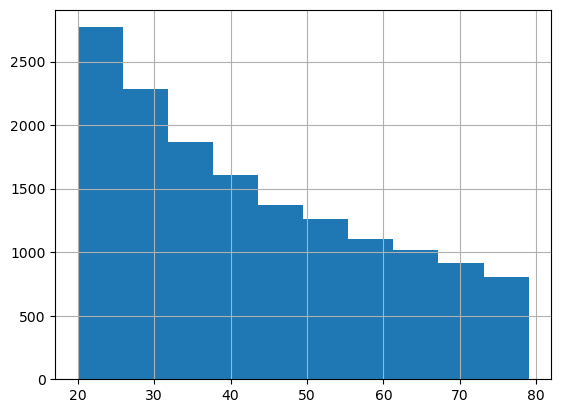

In [ ]:
df.Age.hist()

<Axes: >

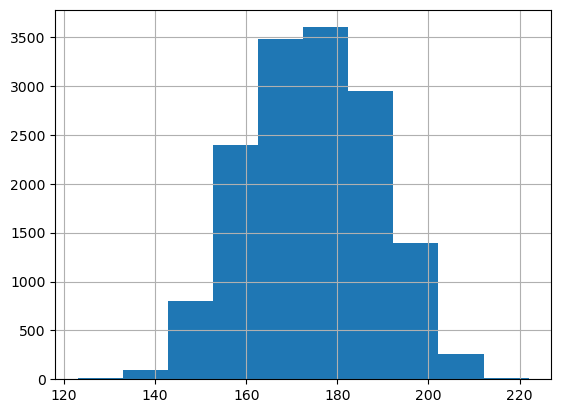

In [ ]:
df.Height.hist()

<Axes: >

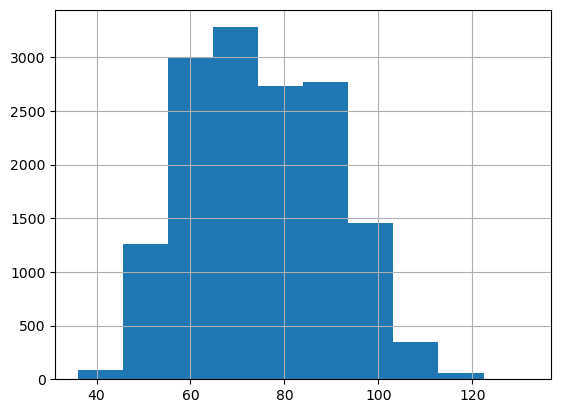

In [ ]:
df.Weight.hist()

<Axes: >

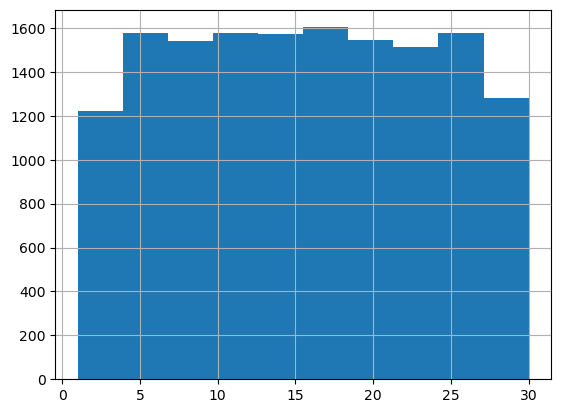

In [ ]:
df.Duration.hist()

<Axes: >

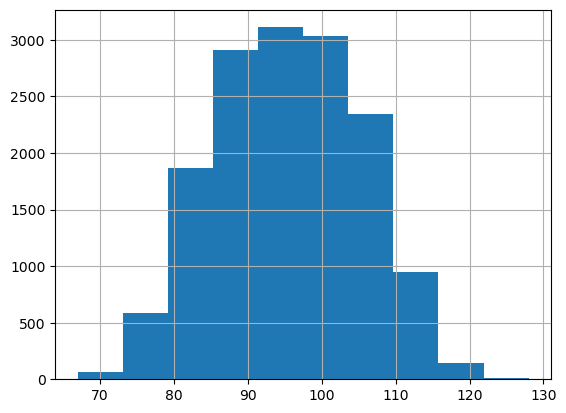

In [ ]:
df.Heart_Rate.hist()

<Axes: >

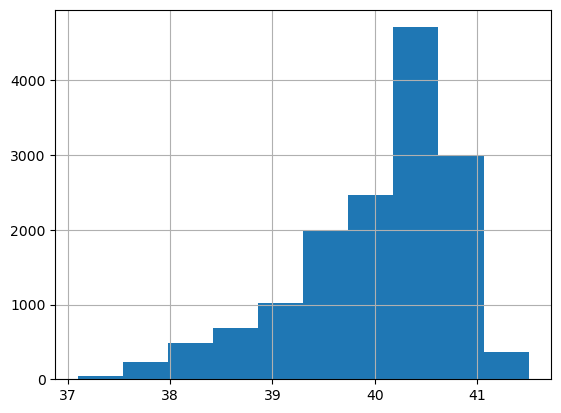

In [ ]:
df.Body_Temp.hist()

In [ ]:
df.Gender.value_counts(normalize=True).mul(100).round(2)

Gender
female    50.35
male      49.65
Name: proportion, dtype: float64

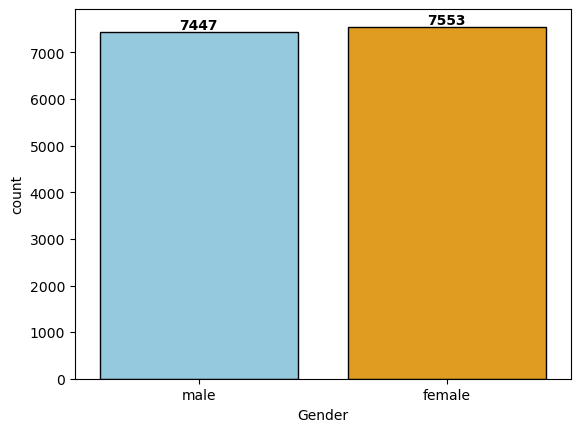

In [ ]:
ax=sns.countplot(data=df,x='Gender',palette=['skyblue','orange'],edgecolor='black')
for i in ax.containers:
    ax.bar_label(i,fontsize=10,fontweight='bold')


In [ ]:
for i in df.select_dtypes(include='number'):
    if i !='user_id':
        fig=px.histogram(df,df[i],color_discrete_sequence=['skyblue','orange'],title=i,color='Gender')
        fig.show()

In [ ]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='object')

In [ ]:
data_grobing=df.groupby('Gender').median().T
data_grobing

Gender,female,male
User_ID,14986208.0000,15006801.0000
Age,40.0000,39.0000
Height,164.0000,185.0000
Weight,63.0000,87.0000
Duration,16.0000,15.0000
Heart_Rate,95.0000,96.0000
Body_Temp,40.2000,40.2000
Calories,80.0000,78.0000


In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
df.groupby('Gender').mean().T

Gender,female,male
User_ID,14979317.4464,14975371.7475
Age,42.7355,42.8449
Height,164.4059,184.6675
Weight,63.2745,86.8257
Duration,15.5022,15.5594
Heart_Rate,95.4086,95.6301
Body_Temp,40.0198,40.0312
Calories,88.1531,90.9457


In [ ]:
import plotly.express as px

fig = px.scatter(df, x='Duration', y='Calories')
fig.show()


In [ ]:
fig = px.scatter(df, x='Heart_Rate', y='Calories', color='Gender')
fig.show()


In [ ]:
import plotly.express as px

fig = px.scatter(df, x='Body_Temp', y='Calories')
fig.show()


In [ ]:
fig=px.scatter(df,x='Age',y='Calories')
fig.show()

In [ ]:
fig=px.scatter(df,x='Height',y='Calories')
fig.show()

In [ ]:
fig=px.scatter(df,x='Weight',y='Calories')
fig.show()

In [ ]:
fig=px.scatter(df,x='Height',y='Weight',size='Calories',color='Gender')
fig.show()

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)


In [ ]:
df.drop(columns=['User_ID','Gender'],inplace=True)

In [ ]:
fig=px.imshow(df.corr(),color_continuous_scale='Blues',text_auto=True)
fig.show()

In [ ]:
data_corr=df.corr()['Calories']
data_corr

Age          0.1544
Height       0.0175
Weight       0.0355
Duration     0.9554
Heart_Rate   0.8979
Body_Temp    0.8246
Calories     1.0000
Name: Calories, dtype: float64

In [ ]:
x = df.drop(columns=['Calories'], axis=1)
y = df.Calories


In [ ]:
mt=mutual_info_regression(x,y,random_state=42)
mt

array([0.03287191, 0.00808649, 0.02175099, 1.50279394, 0.87000313,
       0.98020423])

In [ ]:
mi_scores = pd.Series(mt, index=x.columns)
mutual_score_sort=mi_scores.sort_values()

In [ ]:
fig=px.bar(mutual_score_sort,x=mutual_score_sort.values,y=mutual_score_sort.index)
fig.show()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


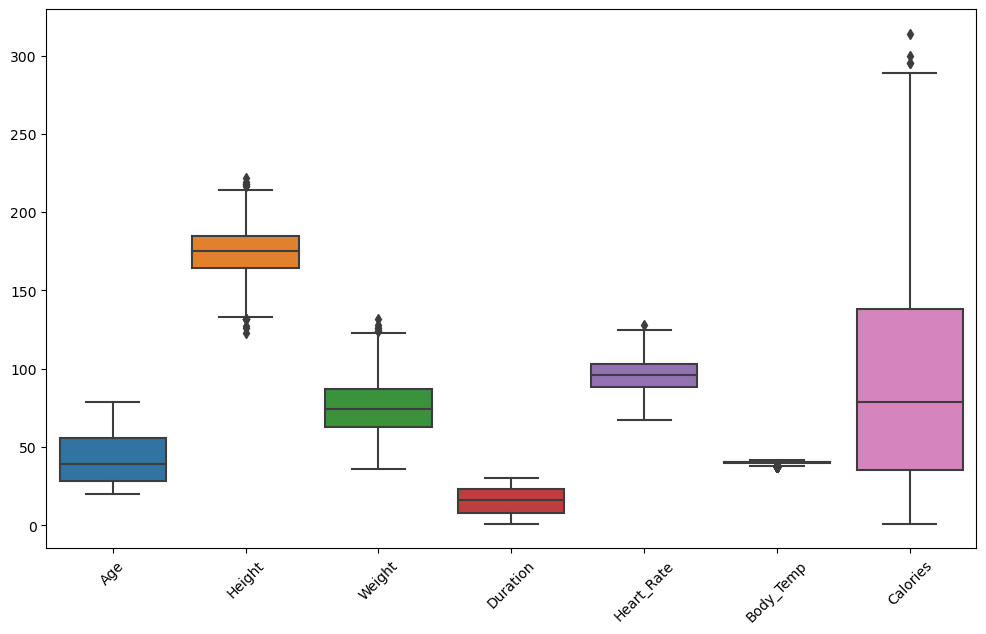

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

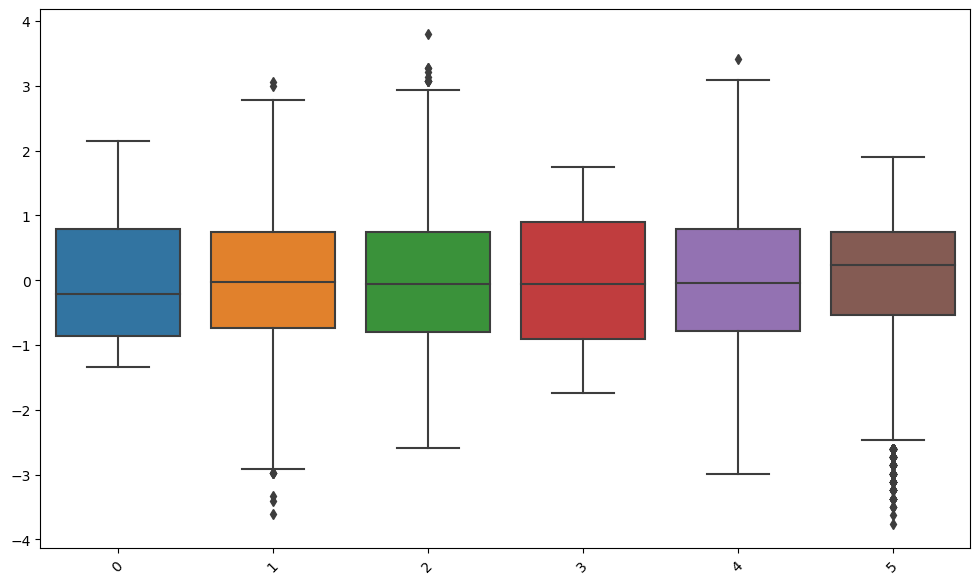

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(x_train)
plt.xticks(rotation=45)
plt.show()

In [ ]:
lr_reg=LinearRegression()
lr_reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr_reg.score(x_train,y_train)

0.9671182859975302

In [ ]:
lr_reg.score(x_test,y_test)

0.9672860085124584

In [ ]:
y_pred=lr_reg.predict(x_test)
y_pred

array([170.84322822, 192.09907567,  56.82549994, ..., 129.36053517,
         2.63595488, 192.22133996])

In [ ]:
mean_absolute_error(y_pred,y_test)

8.43977991130646

In [ ]:
print(lr_reg.coef_)
print(lr_reg.intercept_)

[  8.57628077  -1.99496876   3.35159034  55.03053004  18.98709746
 -13.18011989]
89.09541666666658


In [ ]:
feat_sore=pd.DataFrame({'features':x.columns,
                       'importance':lr_reg.coef_})

In [ ]:
feat_sort=feat_sore.sort_values(by='importance')
fig=px.bar(feat_sort,x='features',y='importance')
fig.show()
